# Varaince Swap Chain
Below is the price chain for variance swaps, these prices are derived from the market and do not attempt to represent a structuring desk quoting a price, more sophisticated volatility modelling is required, which I am studying towards being able to use. I will be shortly adding the code and the pricing documentation.

In [15]:
import matplotlib.pyplot as plt
import pandas as pd   
import yfinance as yf
import numpy as np
import pickle

In [16]:
vix  = yf.download("^VIX", start='2026-01-19')
vix_prices = vix["Close"].squeeze()
with open("new_variance_swap_prices.pkl", "rb") as f:
    options_chain_data = pickle.load(f)

[*********************100%***********************]  1 of 1 completed


In [17]:
var_swap_price_vol = options_chain_data["var_swap_price_vol"]
var_swap_price_vol_bid = options_chain_data["Bid In Vol"]
var_swap_price_vol_ask = options_chain_data["Ask In Vol"]
vega_notional_rounded = options_chain_data["Vega Notional"]
forward_var_surface = options_chain_data["forward_var_surface"]

<Axes: title={'center': 'Variance Swap Prices In Vol by expiry'}, xlabel='expiry', ylabel='Vol Price'>

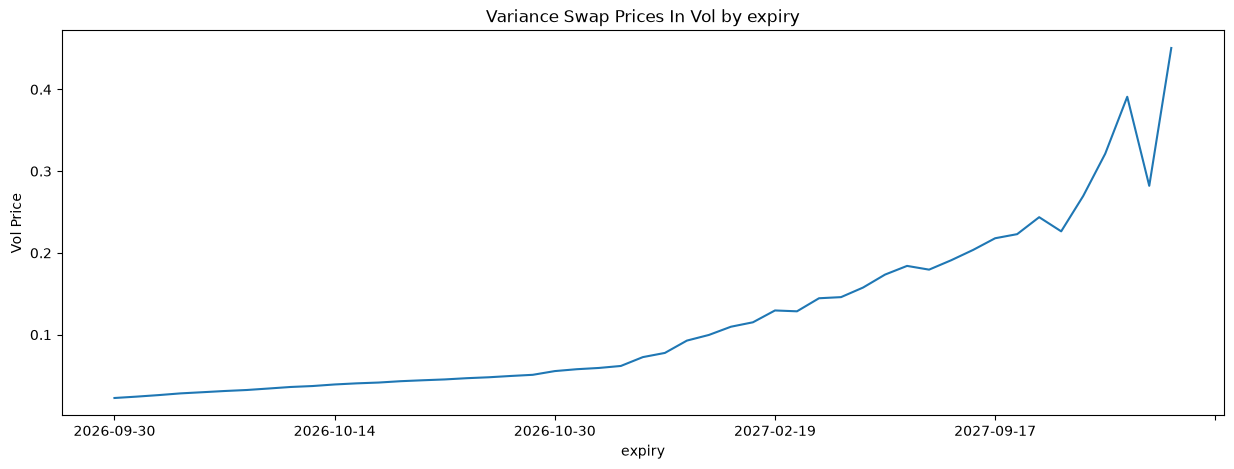

In [21]:
var_swap_price_vol.plot(figsize=(15,5), title='Variance Swap Prices In Vol by expiry', ylabel='Vol Price')

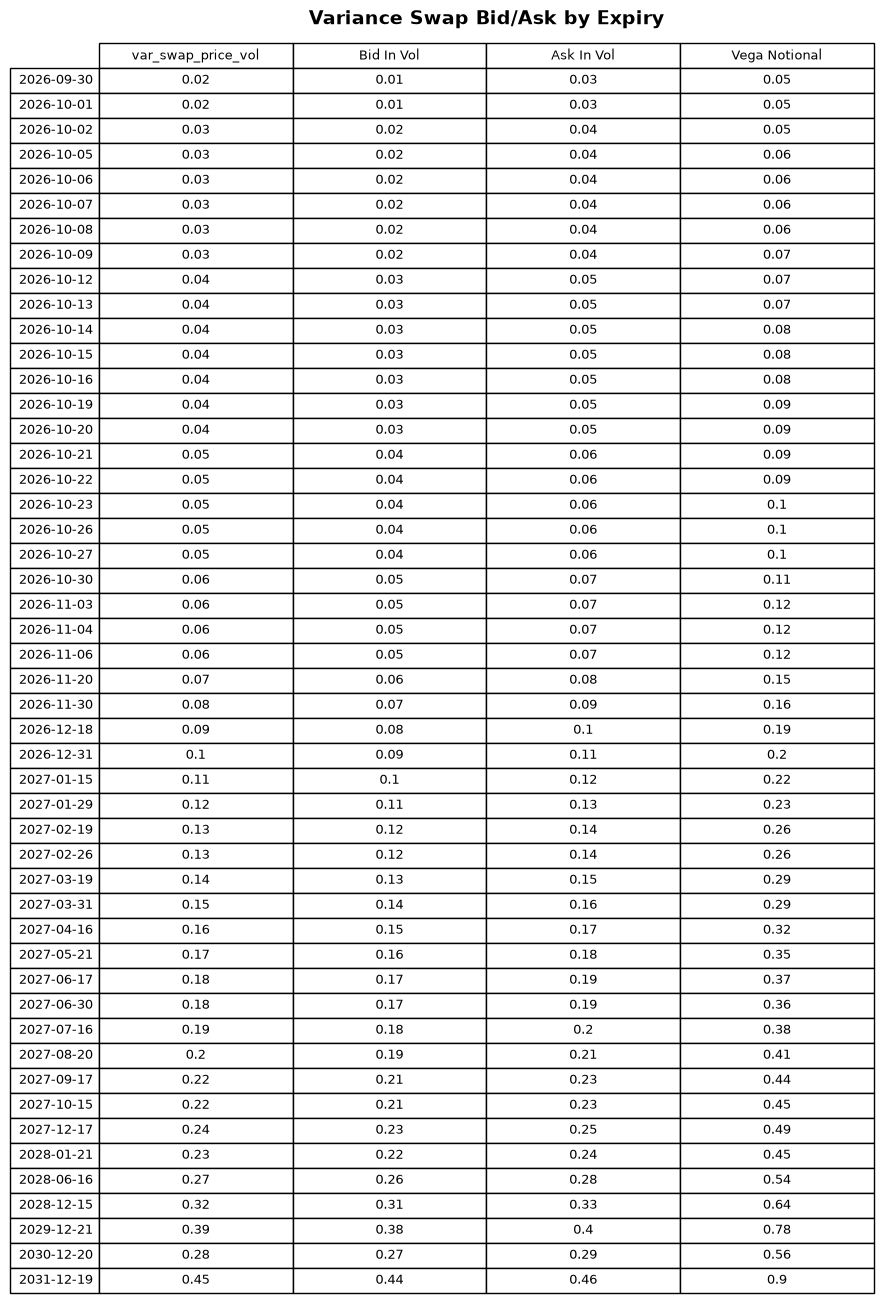

In [20]:
data_V_swap = {
   "var_swap_price_vol": var_swap_price_vol,
    "Bid In Vol": var_swap_price_vol_bid,
    "Ask In Vol": var_swap_price_vol_ask,
    "Vega Notional": vega_notional_rounded,
    
}


data = pd.DataFrame(data_V_swap)
display_data = data.copy()
#display_data["Vega Notional"] = display_data["Vega Notional"].map("${:,.0f}".format)
fig, ax = plt.subplots(figsize=(10, 4))
ax.axis("off")
ax.set_title("Variance Swap Bid/Ask by Expiry", fontsize=14, fontweight="bold", pad=20, y=2.5)
tbl = ax.table(cellText=display_data.round(2).values,
                colLabels=display_data.columns,
                rowLabels=display_data.index,
                loc="center", cellLoc="center")
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.5)
plt.show()